In [36]:
%load_ext autoreload
%autoreload 2

In [8]:
import os 
from pathlib import Path
import xml.etree.ElementTree as ET
from PIL import Image
import shutil
from sklearn.model_selection import train_test_split
import pandas as pd
import torchvision.transforms as transforms 
from torch.utils.data import Dataset, DataLoader
import torch
import matplotlib.pyplot as plt
from FasterRCNN import FasterRCNN
from LossFunction import Encode_rpn_target_and_label,rpn_loss,final_rcnn_loss

In [92]:
file_path = Path('/Users/martins_ml/data')

In [4]:
annotation,Images = [],[]
for root, dirs, files in os.walk(file_path):
    for file in files:
        if file.endswith('.xml'):
            sample_dir = os.path.join(root,file)
            try:
               xml_root = ET.parse(sample_dir).getroot()
            except ET.ParseError as e:
               continue
            annotation.append(sample_dir)
        if file.endswith(('.jpg','.png', '.jpeg')):
            sample_dir = os.path.join(root,file)
            Images.append(sample_dir)
sorted_annotation = sorted(annotation)
sorted_Images  = sorted(Images)
annotaion_train, annotation_test, Image_train, Image_test = train_test_split(sorted_annotation, sorted_Images, test_size= 0.2,  random_state=42, shuffle = True)
splits = { 'Train': (annotaion_train, Image_train),
          'Val':(annotation_test, Image_test)}

destination = '/Users/martins_ml/Documents/GitHub/Computer Vision Learning Journal /data'
for splits, (split_annotation, split_image) in splits.items():
    for subdir in ['Annotation', 'Image']:
        os.makedirs(os.path.join(destination,splits,subdir), exist_ok= True)
    for annotation in split_annotation:
        shutil.move(annotation,os.path.join(destination,splits,'Annotation'))
    for image in split_image:
        shutil.move(image, os.path.join(destination,splits,'Image'))

NameError: name 'file_path' is not defined

In [5]:
folder_extention = '/Train/Annotation'
xml_files_train = destination + folder_extention
for root, dir, files in os.walk(xml_files_train):
    for file in files:
        sample_xml = os.path.join(root,file)
        break 
sample_xml

NameError: name 'destination' is not defined

In [6]:
class CustomDataset(Dataset):
    def __init__(self,data, image_size = (224,224), augment= False ):
        self.data = data
        if augment:
            self.transform = transforms.Compose([
                                                 transforms.Resize((224,224)),
                                                 transforms.RandomHorizontalFlip(),
                                                 transforms.ToTensor(),
                                                 transforms.Normalize(mean=[0.485, 0.456, 0.406], std =[0.229, 0.224, 0.225])])
        else:
            self.transform = transforms.Compose([
                                                 transforms.Resize((224,224)),
                                                 transforms.ToTensor(),
                                                 transforms.Normalize(mean=[0.485, 0.456, 0.406], std =[0.229, 0.224, 0.225])])
        self.label_map = {
            'with_mask':1,
            'without_mask':0,
            'mask_weared_incorrect':1}
    
    def __getitem__(self,idx):
        img_path, labels, boxes = self.data[idx]
        img = Image.open(img_path).convert('RGB')
        init_img_width, init_img_height = img.size 
        width_scale = 224/ init_img_width
        height_scale = 224/ init_img_height
        img = self.transform(img)
        scaled_boxes = [(x1*width_scale,y1*height_scale, x2*width_scale,y2 * height_scale)  
               for x1,y1,x2,y2 in boxes]
        
        label = [self.label_map[l] for l in labels]
        return img, {'boxes': torch.tensor(scaled_boxes, dtype= torch.float32), 'target': torch.tensor(label, dtype= torch.long)}
    
    def __len__(self):
        return len(self.data)
        

def DataExtraction(dir):
    row = []
    xml_files_path = os.path.join(dir,'Annotation')
    xml_files = [f for f in os.listdir(xml_files_path) if f.endswith('.xml')]
    for xml in xml_files:
        xml = os.path.join(xml_files_path, xml) 
        try:
            root = ET.parse(xml).getroot()
        except ET.ParseError as e:
            continue
        filename = root.find('filename').text
        img = f'{str(dir)}/Image/{filename}'
        labels = [obj.find('name').text for obj in root.findall('object')]
        boundingbox = [(int(obj.find('bndbox').find('xmin').text),
                    int(obj.find('bndbox').find('ymin').text),
                    int(obj.find('bndbox').find('xmax').text),
                    int(obj.find('bndbox').find('ymax').text)) for obj in root.findall('object') ]
        row.append([img,labels, boundingbox])
    return row 

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9124069..2.64].


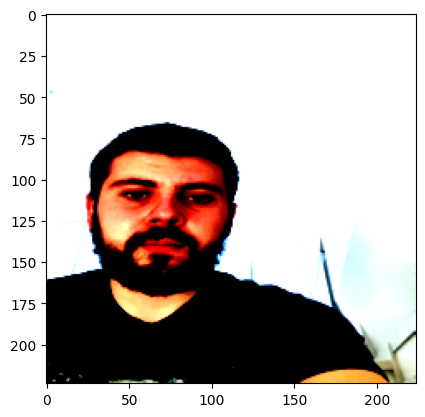

In [7]:
dir_train = '/Users/martins_ml/Documents/GitHub/Computer Vision Learning Journal /data/Train'
dir_test = '/Users/martins_ml/Documents/GitHub/Computer Vision Learning Journal /data/Val'
raw_data_train = DataExtraction(dir_train)
raw_data_test = DataExtraction(dir_test)
data_train = CustomDataset(raw_data_train, augment= True)
data_test = CustomDataset(raw_data_test, augment= False)
a = next(iter(data_test))
a= a[0].cpu().detach().permute(1,2,0)
plt.imshow(a)

In [ ]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
train_dataloader = DataLoader(data_train,batch_size=32,shuffle = True )
test_dataloader = DataLoader(data_test, batch_size= 32)

model = FasterRCNN(num_classes=2, image_shape=(224,224))
optimizer = torch.optim.SGD(model.parameters(),
                            lr = 0.001)
for images,target_dict in train_dataloader:
    images = images.to(device)
    target = target_dict.to(device)
    model.train()
    proposal_boxes,rpn_reg_layer, rpn_cls, anchors, batch_idx=model.rpn(images)
    ground_truth = [t['boxes'] for t in target_dict]
    batch_label, batch_target = [],[]
    for i in range(anchors.shape[0]):
        anchor = anchors[i]
        gt_box = ground_truth[i]
        labels, target = Encode_rpn_target_and_label(anchor,ground_truth[i])
        batch_label.append(labels)
        batch_target.append(target)
    rpn_label = torch.stack(batch_label)
    rpn_target = torch.stack(batch_target)
    rpn_cls_loss, rpn_delta_loss = rpn_loss(rpn_cls,rpn_reg_layer,rpn_label,rpn_target)
    final_cls, final_delta = model(images)
    final_cls_loss, final_delta_loss = final_rcnn_loss(final_cls,final_delta)


        